[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T04_A_tax_multiplier_three_ways_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# El multiplicador de impuestos, de tres maneras: identificación econométrica y teoría macroeconómica

**¿Qué le ocurre al producto agregado tras un aumento legislado de impuestos equivalente al 1% del PIB?** En la literatura macroeconómica empírica, las tres respuestas canónicas discrepan sustancialmente:
1. **SVAR con rezagos institucionales** ($\approx -1.0$ a $-1.5$, Blanchard y Perotti 2002 QJE)
2. **Proyecciones locales narrativas** ($\approx -3.0$, Romer y Romer 2010 AER)
3. **Instrumentos externos / Proxy-SVAR** ($\approx -2.1$, Mertens y Ravn 2013 AER, 2014 JME)

Esta divergencia no proviene de datos empíricos contradictorios. Las tres metodologías se evalúan aquí sobre el **mismo conjunto congelado de cuentas macroeconómicas trimestrales de EE. UU. (1950Q1–2006Q4)**. Cada diferencia en el multiplicador dinámico estimado obedece exclusivamente a los **supuestos económicos de identificación**, demostrando cómo premisas teóricas contrastantes reconfiguran las conclusiones de política económica.

## Las tres identificaciones en matemáticas

Las tres metodologías parten del mismo VAR en forma reducida en $x_t = (\tau_t, g_t, y_t)'$ — ingresos tributarios federales reales, gasto federal real y PIB real en logaritmos:
$$ x_t = A_1 x_{t-1} + \cdots + A_p x_{t-p} + u_t, \qquad u_t = B\,\varepsilon_t,\quad \Sigma_u = BB'. $$

El desafío econométrico fundamental radica en que las innovaciones en forma reducida $u_t$ combinan el comovimiento cíclico automático con cambios discrecionales de política fiscal. Identificar el choque tributario estructural $\varepsilon^\tau_t$ exige aislar la variación exógena:

**(a) Blanchard-Perotti (2002): rezagos de decisión institucional y elasticidad automática**  
La política fiscal discrecional requiere aprobación legislativa (propuesta, debate, votación y promulgación), proceso que toma al menos un trimestre completo. Dentro de un trimestre ($t$), las autoridades no pueden reaccionar a innovaciones contemporáneas del producto ($u^y_t$). Por consiguiente, la relación contemporánea entre recaudación y producto refleja *únicamente* estabilizadores automáticos:
$$ u^\tau_t = \theta\,u^y_t + \varepsilon^\tau_t, \qquad u^g_t = c\,\varepsilon^\tau_t + \varepsilon^g_t, \qquad u^y_t = b_\tau u^\tau_t + b_g u^g_t + \varepsilon^y_t. $$
Utilizando información desglosada del código tributario y cuentas nacionales, BP calculan la elasticidad institucional de la recaudación neta respecto al producto en $\theta = 2.08$. Purgar $\theta u^y_t$ aísla la innovación fiscal ajustada por ciclo $\varepsilon^\tau_t$, que sirve de instrumento para identificar la ecuación del producto. Con la restricción de ordenamiento fiscal $b_{12}=0$ (los impuestos preceden al gasto), el sistema satisface $\Sigma_u = BB'$.

**(b) Romer-Romer (2010): identificación narrativa de choques exógenos**  
Romer y Romer prescinden de las restricciones de covarianza examinando discursos presidenciales, debates del Congreso e informes de presupuesto. Clasifican los cambios tributarios según su motivación, reteniendo solo aquellos diseñados para reducir déficits heredados o fomentar el crecimiento de largo plazo (purgando estímulos contracíclicos y medidas vinculadas al gasto). Al incorporar esta serie narrativa $z_t$ (en porcentaje del PIB) directamente en una proyección local aumentada con rezagos (Montiel Olea y Plagborg-Møller 2021):
$$ y_{t+h} - y_{t-1} = \alpha_h + m(h)\, z_t + \sum_{j=1}^p \Gamma_{h,j} w_{t-j} + e_{t+h}, $$
donde $m(h)$ traza directamente la trayectoria del multiplicador acumulado dólar por dólar.

**(c) Mertens-Ravn (2013, 2014): Proxy-SVAR narrativo y reconciliación de elasticidades**  
Mertens y Ravn combinan el registro narrativo con el marco del VAR estructural empleando la serie narrativa $z_t$ como un **instrumento externo** (proxy) para el choque tributario estructural $\varepsilon^\tau_t$:
$$ \mathbb{E}[z_t \varepsilon^\tau_t] = \phi \neq 0, \qquad \mathbb{E}[z_t \varepsilon^{-\tau}_t] = 0 \;\Longrightarrow\; B_{\cdot 1} \propto \Sigma_u \Pi, \quad \Pi = \mathbb{E}[u_t z_t] / \mathbb{E}[z_t^2]. $$
Este método protege al choque estructural del error de medición clásico en las magnitudes proyectadas. Además, Mertens y Ravn (2014) demuestran que la información narrativa identifica endógenamente la elasticidad intra-trimestral en aproximadamente $\theta = 3.13$. Al introducir $\theta = 3.13$ en el SVAR de Blanchard-Perotti, ambas metodologías se reconcilian en un multiplicador a dos años de $\approx -2.1$ (pico $\approx -2.4$).

**(d) La Integral del Multiplicador Acumulado (Mountford y Uhlig 2009; Ramey 2016; Ramey y Zubairy 2018)**  
Cuando las perturbaciones fiscales persisten a lo largo de múltiples trimestres, los multiplicadores puntuales instantáneos $m(h) = y_h / \tau_0 \times (Y/T)$ distorsionan el costo real en producto por cada dólar de recaudación tributaria obtenida. La métrica teóricamente rigurosa es la integral del multiplicador acumulado:
$$ \mathcal{M}_{cum}(H) = \frac{\int_0^H \Delta Y_h\, dh}{\int_0^H \Delta T_h\, dh} \approx \frac{\sum_{h=0}^H \Delta Y_h}{\sum_{h=0}^H \Delta T_h} = \frac{\int_0^H y_h\, dh}{\int_0^H (\tau_h / \tau_0)\, dh} $$
evaluada mediante integración numérica trapezoidal (`np.trapezoid`).

**Normalización.** Cada choque se normaliza para que los impuestos aumenten en un 1% del PIB en el impacto: $\Delta\tau_0 = (Y/T)\times 1\%$ en puntos logarítmicos. La respuesta porcentual resultante del PIB real corresponde directamente al multiplicador acumulado dólar por dólar.

**Intuición macroeconómica.** En datos observacionales brutos, los ingresos fiscales y el PIB comueven con fuerza: las recesiones recortan la recaudación automáticamente mediante tramos progresivos y menores beneficios empresariales ($\alpha_{ty} > 0$), mientras que los gobiernos suelen aprobar alivios fiscales contracíclicos. Los mínimos cuadrados ordinarios están contaminados por causalidad simultánea. Cada metodología resuelve este dilema con supuestos teóricos distintos:
- Blanchard y Perotti aportan un **hecho institucional**: los rezagos legislativos garantizan que la reacción contemporánea sea puramente automática.
- Romer y Romer aportan **archivos históricos**: la intención legislativa identifica motivaciones independientes del ciclo económico.
- Mertens y Ravn aportan un **puente econométrico**: las fechas narrativas identifican las innovaciones del VAR sin requerir mediciones exactas del impacto recaudatorio.

Dado que cada estrategia adopta premisas de identificación diferentes, sus respuestas de política divergen. Comparar las tres permite comprender cómo los supuestos estructurales determinan las conclusiones empíricas.

## Preparación — un único conjunto de datos congelado

Utilizamos series macroeconómicas y narrativas oficiales congeladas:
- `tax14_us_fiscal.csv` — Agregados trimestrales de EE. UU. desde FRED: PIB real (`GDPC1`), PIB nominal (`GDP`), deflactor del PIB (`GDPDEF`), ingresos tributarios federales (`W006RC1Q027SBEA`), gasto federal (`FGEXPND`) e IPC (`CPIAUCSL`).
- `tax14_narrative_tax_shocks.csv` — Medidas narrativas en % del PIB del archivo del Handbook of Macroeconomics de Valerie Ramey: cambios exógenos de Romer-Romer (`rr_exog`), choques no anticipados de Mertens-Ravn (`mtr_u`) y choques anticipados (`mtr_a`).
- `USREC.csv` — Fechas mensuales de recesión de NBER desde FRED, remuestreadas a frecuencia trimestral para identificar fases del ciclo económico en proyecciones locales dependientes del estado.
- `rz2018.csv` — Archivo fiscal histórico (Ramey y Zubairy 2018 JPE; Ramey 2016): suministra la serie de choques narrativos de noticias de gasto militar (`news`), en miles de millones de dólares nominales (no se divide por el PIB).

Todas las estimaciones se evalúan sobre la muestra canónica 1950Q1–2006Q4.

In [2]:
import sys
from importlib import resources
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv
from puremacro.narrative.replication import load_romer_romer_2010, load_mertens_ravn_2013
from puremacro.var.estimate import estimate_var
from puremacro.var.irf import irf as var_irf
from puremacro.inference.wild_bootstrap import wild_bootstrap_var
from puremacro.inference.weak_iv import olea_pflueger_f
from puremacro.var.identify.proxy import proxy_svar
from puremacro.lp.la_lp import la_lp
from puremacro.lp.state_dep import lp_state_dep
from puremacro.regress import ols, add_constant
from puremacro.inference.spec_curve import enumerate_specs, run_spec_curve
from puremacro.dsge import load_mod
from puremacro.reports import df_to_latex, df_to_typst, df_to_markdown

# --- Agregados fiscales congelados (instantánea fredgraph) -------------------
fiscal = load_csv("tax14_us_fiscal")
fiscal["date"] = pd.to_datetime(fiscal["date"])
fiscal = fiscal.set_index("date")

# --- Medidas narrativas mediante cargadores del paquete -----------------------
NARR_CSV = str(resources.files("puremacro.replication.data")
               .joinpath("tax14_narrative_tax_shocks.csv"))
rr_inst = load_romer_romer_2010(csv_path=NARR_CSV)               # columna rr_exog
mr_u_inst = load_mertens_ravn_2013(csv_path=NARR_CSV, kind="unanticipated")
mr_a_inst = load_mertens_ravn_2013(csv_path=NARR_CSV, kind="anticipated")

# --- Archivo de choques de noticias de defensa de Ramey (2016) / RZ (2018) ---
rz_df = load_csv("rz2018")
rz_df["date"] = pd.to_datetime(rz_df["date"])
rz_df = rz_df.set_index("date")

# --- Indicador de recesiones NBER para proyecciones dependientes del estado ---
data_curso = _cwd / "data_curso" if (_cwd / "data_curso").exists() else _cwd / "notebooks" / "data_curso"
usrec_raw = pd.read_csv(data_curso / "USREC.csv")
usrec_raw["date"] = pd.to_datetime(usrec_raw["observation_date"])
usrec_raw = usrec_raw.set_index("date")
usrec_q = usrec_raw["USREC"].resample("QS").max()

print(f"narrative events: RR exogenous = {len(rr_inst.events)}, "
      f"MR unanticipated = {len(mr_u_inst.events)}, "
      f"MR anticipated = {len(mr_a_inst.events)}, "
      f"Ramey defense news = {(rz_df['news'] != 0).sum()}")

def build_dataset(t0, t1, deflator="gdpdef"):
    ds = fiscal.loc[t0:t1].copy()
    ds["tau"] = 100 * np.log(ds["fedtax"] / ds[deflator])
    ds["g"]   = 100 * np.log(ds["fedspend"] / ds[deflator])
    ds["y"]   = 100 * np.log(ds["gdpc1"])
    ds["rr"]  = rr_inst.quarterly.reindex(ds.index).fillna(0.0)
    ds["mtu"] = mr_u_inst.quarterly.reindex(ds.index).fillna(0.0)
    ds["mta"] = mr_a_inst.quarterly.reindex(ds.index).fillna(0.0)
    ds["ramey_news"] = rz_df["news"].reindex(ds.index).fillna(0.0)
    ds["usrec"] = usrec_q.reindex(ds.index).fillna(0.0).astype(int)
    return ds

d = build_dataset("1950-01-01", "2006-12-31")
P, H = 4, 16
SCALE = 1.0 / (d["fedtax"] / d["gdp"]).mean()
hgrid = np.arange(H + 1)
print(f"sample: {d.index[0].date()} .. {d.index[-1].date()}  (T = {len(d)})")
print(f"mean federal tax / GDP = {1/SCALE:.3f}  ->  a 1%-of-GDP tax increase raises revenue by {SCALE:.1f}%")

narrative events: RR exogenous = 45, MR unanticipated = 31, MR anticipated = 23, Ramey defense news = 112
sample: 1950-01-01 .. 2006-10-01  (T = 228)
mean federal tax / GDP = 0.121  ->  a 1%-of-GDP tax increase raises revenue by 8.3%


### El registro narrativo de un vistazo (Impuestos Romer-Romer vs Noticias de Defensa Ramey)

Antes de estimar los modelos econométricos, examinamos la distribución temporal y la frecuencia de los choques identificados. Romer y Romer (2010) identifican 45 trimestres exógenos, motivados principalmente por consolidación fiscal (p. ej., OBRA 1990 y 1993) o crecimiento de largo plazo (p. ej., recortes Kennedy-Johnson y Reagan 1981). Mertens y Ravn (2013) descomponen estos eventos en sorpresas no anticipadas y anuncios anticipados con rezago de implementación. En paralelo, la serie de noticias de defensa de Valerie Ramey (2016), en miles de millones de dólares nominales, registra 112 trimestres con revisiones de gasto geopolítico en todo el archivo (1889–2015), de los cuales 66 caen dentro de la muestra 1950–2006 que dibuja la franja C.

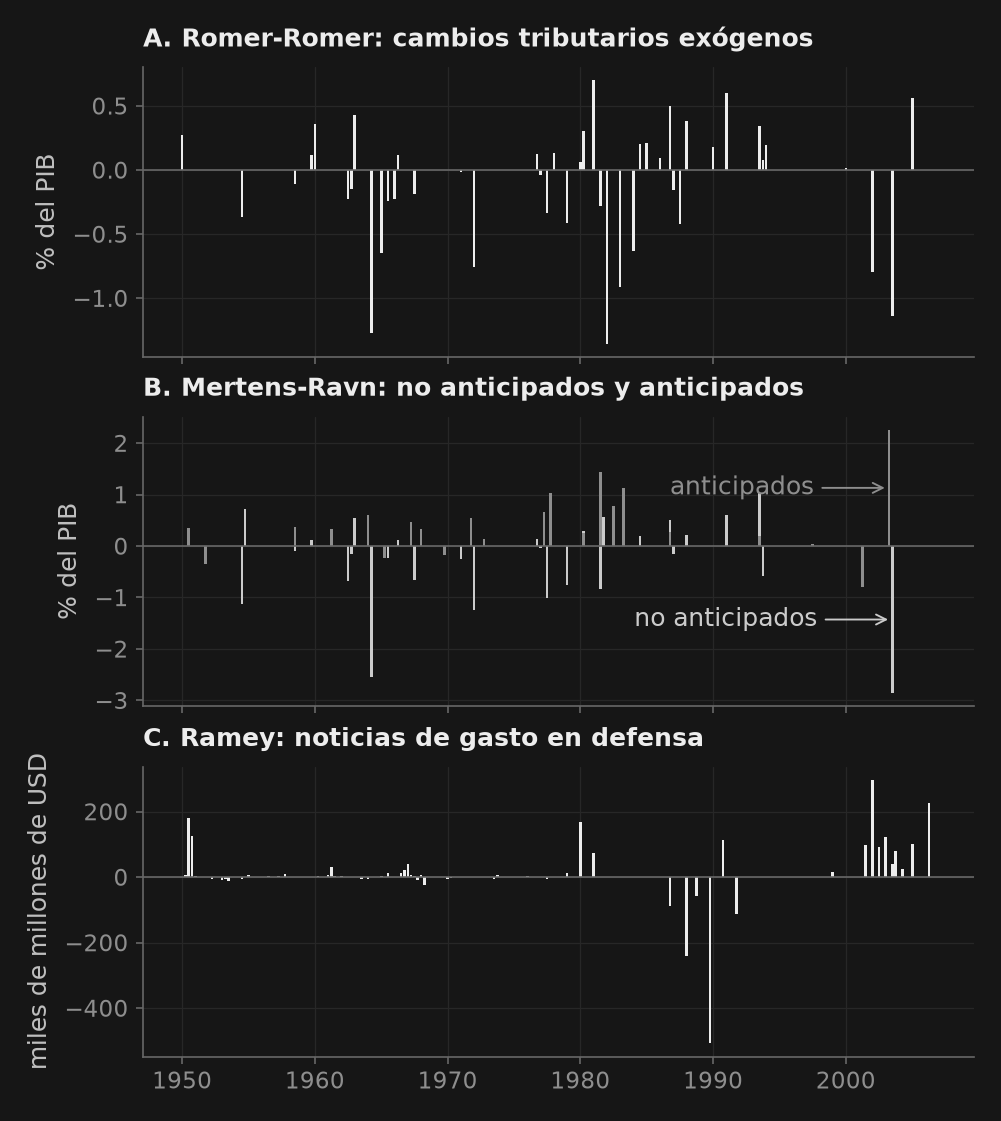

In [3]:
# Tres franjas apiladas de series trimestrales: TAMANO no tiene clave 3x1 y
# la altura automática (10.2 in) dejaría cada franja demasiado alta.
fig, (ax1, ax2, ax3) = _nbstyle.figura(3, 1, figsize=(6.4, 7.2), sharex=True)
ax1.bar(d.index, d["rr"], width=70, color=_nbstyle.TINTA)
ax1.set_ylabel("% del PIB")
ax1.set_title("A. Romer-Romer: cambios tributarios exógenos")

c_mtu, c_mta = _nbstyle.BARRA_COLORES[0], _nbstyle.BARRA_COLORES[1]
ax2.bar(d.index, d["mtu"], width=70, color=c_mtu)
ax2.bar(d.index, d["mta"], width=70, color=c_mta)
ax2.set_ylabel("% del PIB")
ax2.set_title("B. Mertens-Ravn: no anticipados y anticipados")
# cada serie se nombra, en su propio tono, junto a su cambio de mayor magnitud
for serie, nombre, col in [(d["mtu"], "no anticipados", c_mtu),
                           (d["mta"], "anticipados", c_mta)]:
    t = serie.abs().idxmax()
    ax2.annotate(nombre, xy=(t, serie[t] / 2), xytext=(-36, 0), textcoords="offset points",
                 ha="right", va="center", color=col,
                 arrowprops={**_nbstyle.FLECHA, "color": col})

ax3.bar(d.index, d["ramey_news"], width=70, color=_nbstyle.TINTA)
ax3.set_ylabel("miles de millones de USD")
ax3.set_title("C. Ramey: noticias de gasto en defensa")
for ax in (ax1, ax2, ax3):
    ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8)
plt.show()


## 1. Blanchard-Perotti (2002): la elasticidad institucional

La identificación de Blanchard-Perotti se articula alrededor de un parámetro institucional clave: $\theta = 2.08$, la elasticidad intra-trimestral de los ingresos tributarios federales respecto al producto. Como el proceso legislativo requiere al menos un trimestre completo entre deliberación y promulgación, la política tributaria discrecional no puede responder contemporáneamente a choques de producto.

La matriz de impacto estructural $B$ se construye:
1. Purgando la respuesta automática del ciclo: $\varepsilon^\tau_t = u^\tau_t - \theta u^y_t$.
2. Permitiendo que el gasto público reaccione al choque impositivo dentro del trimestre pero no al producto contemporáneo (los impuestos preceden al gasto: $b_{12}=0$).
3. Empleando ambas innovaciones fiscales ortogonales como instrumentos para la ecuación del producto.

Esto identifica completamente el sistema y garantiza que $\Sigma_u = BB'$.

In [4]:
def make_bp_impact(theta):
    """Blanchard-Perotti (2002 QJE) impact matrix on [tau, g, y] residuals."""
    def bp_impact(A_list, Sigma, resid):
        u_tau, u_g, u_y = resid[:, 0], resid[:, 1], resid[:, 2]
        e_tau = u_tau - theta * u_y            # cyclically-adjusted tax shock
        # Third BP restriction: within the quarter neither fiscal variable reacts
        # to output, but ONE of them may react to the other. BP close the system
        # with an ordering; here taxes come first (b_12 = 0), so the spending
        # shock is the part of u_g orthogonal to e_tau. Without this the two
        # fiscal shocks stay correlated and Sigma_u != BB'.
        c = float(e_tau @ u_g / (e_tau @ e_tau))
        e_g = u_g - c * e_tau
        Z = np.column_stack([e_tau, e_g])      # valid instruments for the y equation
        X = np.column_stack([u_tau, u_g])
        b = np.linalg.solve(Z.T @ X, Z.T @ u_y)   # IV: u_y = b1*u_tau + b2*u_g + e_y
        e_y = u_y - X @ b
        A0 = np.array([[1.0,   0.0,   -theta],       # u_tau - theta*u_y       = e_tau
                       [-c,    1.0,    c * theta],   # u_g   - c*e_tau         = e_g
                       [-b[0], -b[1],  1.0]])        # u_y - b1*u_tau - b2*u_g = e_y
        E = np.column_stack([e_tau, e_g, e_y])       # mutually orthogonal by construction
        dof = Sigma[0, 0] / float(u_tau @ u_tau)     # match estimate_var's dof scaling
        return np.linalg.inv(A0) * np.sqrt((E ** 2).sum(axis=0) * dof)
    return bp_impact

THETA_BP = 2.08
Y_var = d[["tau", "g", "y"]].to_numpy()

# The identification is only complete if the impact matrix reproduces the
# reduced-form covariance: Sigma_u = BB' with E[eps eps'] = I.
_est_chk = estimate_var(Y_var, P)
_B_chk = make_bp_impact(THETA_BP)(_est_chk.A_list, _est_chk.Sigma, _est_chk.resid)
assert np.abs(_est_chk.Sigma - _B_chk @ _B_chk.T).max() < 1e-8
pt, lo, hi = wild_bootstrap_var(Y_var, p=P, horizon=H,
                                impact_fn=make_bp_impact(THETA_BP),
                                n_boot=200, ci=0.9, seed=0)
pt, lo, hi = [np.transpose(a, (2, 0, 1)) for a in (pt, lo, hi)]   # -> (H+1, n, n)
c_bp = SCALE / pt[0, 0, 0]                 # rescale: tax impact = 1% of GDP
m_bp, m_bp_lo, m_bp_hi = pt[:, 2, 0] * c_bp, lo[:, 2, 0] * c_bp, hi[:, 2, 0] * c_bp
bp_peak = m_bp[:13].min()
print(f"BP multiplier: impact {m_bp[0]:+.2f} | 2yr {m_bp[8]:+.2f} | "
      f"peak {bp_peak:+.2f} at h={int(m_bp[:13].argmin())}")
assert m_bp[0] > -1.0                          # small impact effect...
assert -2.2 < m_bp[8] < -0.6                   # ...builds toward ~ -1
assert -2.6 < bp_peak < -0.9                   # BP's published ballpark

BP multiplier: impact -0.21 | 2yr -1.25 | peak -1.55 at h=12


**Mecanismo de transmisión económica.** La respuesta de impacto de Blanchard-Perotti está restringida por diseño institucional: la recaudación neta responde al producto mediante estabilizadores automáticos ($\theta = 2.08$), dejando la innovación fiscal ajustada por ciclo casi incorrelada con el producto contemporáneo ($m(0) \approx -0.21$). A lo largo de los dos a tres años posteriores, el efecto contractivo se profundiza a medida que se acumulan las distorsiones en inversión, oferta laboral y acumulación de capital, alcanzando $-1.25$ a los ocho trimestres y un pico de $-1.55$ al trimestre 12 — el resultado clásico de Blanchard y Perotti de aproximadamente "un dólar de pérdida de producto por cada dólar de aumento impositivo".

## 2. Romer-Romer (2010): la regresión narrativa

Romer y Romer evitan el marco del SVAR identificando la legislación fiscal directamente en los registros históricos. Al introducir la serie narrativa $z_t$ (en % del PIB) en una proyección local aumentada con rezagos, estimamos la función de respuesta al impulso horizonte por horizonte. La variable dependiente está en diferencias ($y_{t+h} - y_{t-1}$), por lo que el coeficiente representa directamente el cambio en el nivel del PIB en el horizonte $h$ ante un choque impositivo inicial del 1% del PIB.

In [5]:
H_LP = 20      # LP horizons; lag augmentation p_aug = 4 + 20 (PMW 2021 default)
lp_rr = la_lp(d, y="y", x="rr", horizons=range(0, H_LP + 1), n_lags=4, alpha=0.10)
m_rr, m_rr_lo, m_rr_hi = (lp_rr["beta"].to_numpy(), lp_rr["lo"].to_numpy(),
                          lp_rr["hi"].to_numpy())
rr_peak = m_rr[:13].min()
rr_peak_h = int(m_rr[:13].argmin())
print(f"RR multiplier: impact {m_rr[0]:+.2f} | 2yr {m_rr[8]:+.2f} | "
      f"peak {rr_peak:+.2f} at h={rr_peak_h}")
assert -4.5 < rr_peak < -1.8                       # RR's published -2.5..-3 zone
assert 4 <= rr_peak_h <= 12
assert abs(rr_peak) > abs(bp_peak) + 0.5           # narrative >> SVAR, same data

RR multiplier: impact -0.29 | 2yr -3.15 | peak -3.15 at h=8


**Mecanismo de transmisión económica.** Sobre las mismas cuentas trimestrales, la proyección local narrativa produce un multiplicador fiscal acumulado de **$-3.15$ a los dos años** (pico $\approx -3.15$ en $h=8$) — más del doble que la estimación de Blanchard-Perotti. Al medir los cambios legislados directamente desde las actas del Congreso sin filtrarlos por la recaudación tributaria observada, la serie narrativa evita el sesgo de atenuación originado por la contracción endógena de las bases imponibles.

## 3. Mertens-Ravn (2013): lo narrativo como instrumento externo

Mertens y Ravn combinan la información narrativa con los VARs estructurales utilizando la serie narrativa como un **instrumento externo (proxy)** para la innovación fiscal del VAR. Esto protege la estimación contra errores de medición en la recaudación proyectada: siempre que las fechas de los choques sean exógenas y correlacionen con la innovación fiscal verdadera, la columna de impacto estructural $B_{\cdot 1}$ queda consistentemente identificada.

No obstante, la validez del método requiere relevancia del instrumento. Evaluamos la fuerza de la primera etapa mediante el estadístico $F$ efectivo de Montiel Olea y Pflueger (2013) entre las series candidatas: la medida completa de Romer-Romer, los choques no anticipados de Mertens-Ravn y los choques anticipados.

In [6]:
est = estimate_var(Y_var, P)
u_tau = est.resid[:, 0]
f_stats = {}
for name, col in [("RR exogenous (all)", "rr"),
                  ("MR unanticipated", "mtu"),
                  ("MR anticipated", "mta")]:
    z = d[col].to_numpy()[-len(u_tau):]           # align to VAR residuals
    f_stats[name] = olea_pflueger_f(u_tau, z.reshape(-1, 1))
    res_fs = ols(u_tau, add_constant(z), cov_type="HAC", cov_kwds={"maxlags": 4})
    f_ols = float(res_fs.tvalues[1] ** 2 if hasattr(res_fs.tvalues, "__getitem__") else res_fs.tvalues.iloc[1] ** 2)
    print(f"F efectiva primera etapa | {name:20s} = {f_stats[name]:6.2f} | F MCO = {f_ols:6.2f} (R^2 = {res_fs.rsquared:.4f})")
assert f_stats["MR anticipated"] < f_stats["MR unanticipated"] < f_stats["RR exogenous (all)"]
assert f_stats["MR unanticipated"] < 10.0         # weak proxy on aggregate revenue data

prox = proxy_svar(Y_var, p=P, horizon=H,
                  instrument_series=d["mtu"].to_numpy(),
                  n_boot=200, ci=0.9, seed=0)
c_pr = SCALE / prox.irf_point[0, 0, 0]
m_prox = prox.irf_point[:, 2, 0] * c_pr
print(f"MR proxy-SVAR: effective F = {prox.first_stage_F:.2f} | "
      f"impact {m_prox[0]:+.2f} | 2yr {m_prox[8]:+.2f} | 3yr {m_prox[12]:+.2f}")
assert prox.first_stage_F < 10.0                  # weak proxy instrument on aggregate receipts
assert m_prox[8] < -3.0                           # weak first stage inflates point estimate

F efectiva primera etapa | RR exogenous (all)   =   5.34 | F MCO =   6.06 (R^2 = 0.0357)
F efectiva primera etapa | MR unanticipated     =   1.38 | F MCO =   1.35 (R^2 = 0.0125)
F efectiva primera etapa | MR anticipated       =   0.06 | F MCO =   0.07 (R^2 = 0.0001)
MR proxy-SVAR: effective F = 1.38 | impact -2.47 | 2yr -4.32 | 3yr -4.54


**Diagnóstico econométrico: instrumentos débiles en datos agregados.** Sobre los ingresos federales agregados, el proxy narrativo adolece de una severa debilidad de instrumento: el estadístico $F$ efectivo de Montiel Olea y Pflueger (2013) es de apenas $1.38$ para choques no anticipados (y $0.06$ para choques anticipados, confirmando la previsión fiscal). Con una $F$ efectiva $< 10$, la normalización divide entre una covarianza de primera etapa ruidosa y cercana a cero, provocando que la estimación puntual se disperse hasta $-4.32$ con amplios intervalos de confianza (Jentsch y Lunsford 2019). Mertens y Ravn (2013) resuelven este problema utilizando tasas impositivas medias desglosadas (renta personal y sociedades), donde la primera etapa es sólida ($F > 15$).

Para reconciliar la literatura macroeconómica en datos agregados, Mertens y Ravn (2014 JME) extraen la lección narrativa por otra vía: la evidencia narrativa indica que la verdadera elasticidad intra-trimestral de la recaudación respecto al producto es **$\theta = 3.13$**, no $2.08$. El $2.08$ de Blanchard y Perotti resulta bajo porque las tablas impositivas subestiman la sensibilidad cíclica inmediata de los beneficios corporativos y las compensaciones variables.

In [7]:
THETA_MR = 3.13     # Mertens-Ravn (2014 JME): narrative-implied tax-output elasticity
pt2, lo2, hi2 = wild_bootstrap_var(Y_var, p=P, horizon=H,
                                   impact_fn=make_bp_impact(THETA_MR),
                                   n_boot=200, ci=0.9, seed=0)
pt2, lo2, hi2 = [np.transpose(a, (2, 0, 1)) for a in (pt2, lo2, hi2)]
c_mr = SCALE / pt2[0, 0, 0]
m_mr, m_mr_lo, m_mr_hi = pt2[:, 2, 0] * c_mr, lo2[:, 2, 0] * c_mr, hi2[:, 2, 0] * c_mr
mr_peak = m_mr[:13].min()
print(f"MR (theta=3.13) multiplier: impact {m_mr[0]:+.2f} | 2yr {m_mr[8]:+.2f} | "
      f"peak {mr_peak:+.2f} at h={int(m_mr[:13].argmin())}")
# The reconciliation lands between BP and RR — the task's 'three ways' ordering:
assert m_rr[8] < m_mr[8] < m_bp[8] < 0
assert abs(bp_peak) < abs(mr_peak) < abs(rr_peak)

MR (theta=3.13) multiplier: impact -0.86 | 2yr -2.14 | peak -2.42 at h=12


**La gran reconciliación de la elasticidad.** Al imponer la elasticidad implicada por la narrativa $\theta = 3.13$ dentro del mismo SVAR de Blanchard-Perotti, el multiplicador a dos años se sitúa en **$-2.14$** (pico $\approx -2.42$). Este valor se ubica exactamente entre el $-1.25$ de BP y el $-3.15$ de RR, confirmando la intuición macroeconómica central de Mertens y Ravn: la discrepancia entre SVARs y regresiones narrativas no es un conflicto metodológico de estimadores (SVAR vs. LP); es un desacuerdo económico sobre el tamaño de los estabilizadores automáticos ($\theta$). El registro histórico vota sistemáticamente por un ajuste intra-trimestral mayor de la recaudación.

### Identificación empírica: tres metodologías, tres respuestas fiscales

La siguiente figura sintetiza las respuestas dinámicas acumuladas del producto (nivel del PIB en porcentaje por cada aumento tributario inicial de 1% del PIB) bajo los tres esquemas de identificación, junto con bandas de confianza al 90%. La trayectoria del proxy-SVAR sobre datos agregados se representa como una línea de referencia punteada para advertir sobre el riesgo de instrumentos débiles. Los picos de cada trayectoria son $-1.55$ (BP, $h=12$), $-2.42$ (MR reconciliado, $h=12$) y $-3.15$ (RR narrativo, $h=8$); el proxy débil se hunde hasta $-4.54$ al tercer año.

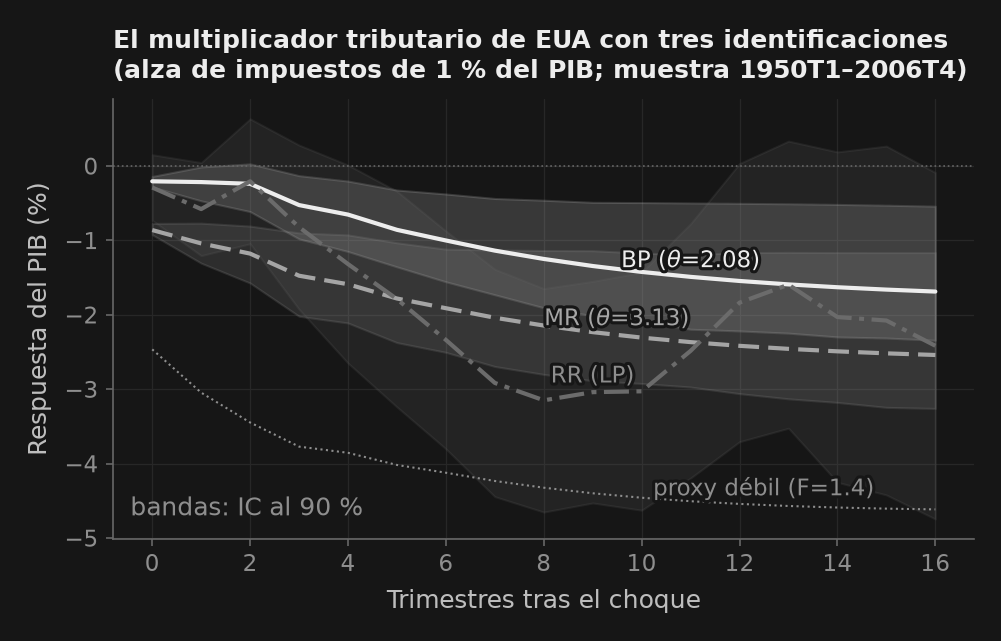

In [8]:
c3 = _nbstyle.palette(3)
fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.fill_between(hgrid, m_bp_lo, m_bp_hi, color=c3[0], alpha=_nbstyle.BANDA_ALPHA)
(l_bp,) = ax.plot(hgrid, m_bp, **_nbstyle.S1, label="BP ($\\theta$=2.08)")
ax.fill_between(hgrid, m_mr_lo, m_mr_hi, color=c3[1], alpha=_nbstyle.BANDA_ALPHA)
(l_mr,) = ax.plot(hgrid, m_mr, **_nbstyle.S2, label="MR ($\\theta$=3.13)")
ax.fill_between(hgrid, m_rr_lo[:H + 1], m_rr_hi[:H + 1], color=c3[2], alpha=_nbstyle.BANDA_ALPHA)
(l_rr,) = ax.plot(hgrid, m_rr[:H + 1], **_nbstyle.S3, label="RR (LP)")
(l_px,) = ax.plot(hgrid, m_prox, color=_nbstyle.NOTA, linewidth=1.0, linestyle=":",
                  label=f"proxy débil (F={prox.first_stage_F:.1f})")
ax.set_xlabel("Trimestres tras el choque")
ax.set_ylabel("Respuesta del PIB (%)")
ax.set_title("El multiplicador tributario de EUA con tres identificaciones\n"
             "(alza de impuestos de 1 % del PIB; muestra 1950T1–2006T4)")
ax.annotate("bandas: IC al 90 %", xy=(0.02, 0.04), xycoords="axes fraction",
            ha="left", va="bottom", color=_nbstyle.NOTA)
# Etiquetas directas dentro de los ejes, cada una sobre el tramo donde su
# trayectoria corre sola: así caben también en la ranura de 5,5 x 1,9 pulgadas.
for linea, xpos in [(l_bp, 11.0), (l_mr, 9.5), (l_rr, 9.0), (l_px, 12.5)]:
    _nbstyle.etiquetar(ax, artistas=[linea], donde=xpos)
plt.show()


## 4. La curva de especificaciones — ¿de verdad es la identificación?

Para verificar que estas discrepancias obedecen a la identificación estructural y no a la selección muestral o al deflactor de precios, construimos una **curva de especificaciones** (Simonsohn, Simmons y Nelson 2020) sobre 24 combinaciones de *identificación $\times$ muestra $\times$ deflactor*.

In [9]:
SAMPLES = {"1950-2006": ("1950-01-01", "2006-12-31"),
           "1954-2006": ("1954-01-01", "2006-12-31"),
           "1950-1979": ("1950-01-01", "1979-12-31")}
H8 = 8   # estimand: the two-year multiplier m(8)

def estimator(_, spec):
    ds = build_dataset(*SAMPLES[spec["sample"]], deflator=spec["deflator"])
    sc = 1.0 / (ds["fedtax"] / ds["gdp"]).mean()
    Yv = ds[["tau", "g", "y"]].to_numpy()
    ident = spec["identification"]
    if ident in ("BP 2.08", "MR 3.13"):
        th = 2.08 if ident == "BP 2.08" else 3.13
        p_, l_, h_ = wild_bootstrap_var(Yv, p=P, horizon=H8, n_boot=100,
                                        impact_fn=make_bp_impact(th), ci=0.9, seed=0)
        k = sc / p_[0, 0, 0]
        return {"sigma_hat": p_[2, 0, H8] * k,
                "se": abs(h_[2, 0, H8] - l_[2, 0, H8]) * abs(k) / (2 * 1.645)}
    if ident == "RR LP":
        lp = la_lp(ds, y="y", x="rr", horizons=[H8], n_lags=4, controls=["tau", "g"])
        return {"sigma_hat": float(lp["beta"].iloc[0]), "se": float(lp["se"].iloc[0])}
    pr = proxy_svar(Yv, p=P, horizon=H8, instrument_series=ds["mtu"].to_numpy(),
                    n_boot=100, ci=0.9, seed=0)
    k = sc / pr.irf_point[0, 0, 0]
    return {"sigma_hat": pr.irf_point[H8, 2, 0] * k,
            "se": abs(pr.irf_upper[H8, 2, 0] - pr.irf_lower[H8, 2, 0]) * abs(k) / (2 * 1.645),
            "first_stage_F": pr.first_stage_F}

grid = {"identification": ["BP 2.08", "MR 3.13", "MR proxy", "RR LP"],
        "sample": list(SAMPLES), "deflator": ["gdpdef", "cpi"]}
curve = run_spec_curve(data=None, specs=enumerate_specs(grid), estimator=estimator,
                       ci_level=0.90)
med = curve.groupby("identification")["sigma_hat"].median()
print(curve[["identification", "sample", "deflator", "sigma_hat", "se"]]
      .round(2).to_string(index=False))
print("\nmedian two-year multiplier by identification:")
print(med.round(2).to_string())
assert len(curve) == 24
assert med["RR LP"] < med["BP 2.08"] - 0.5        # la brecha de identificación >> muestra/deflactor
assert med["MR 3.13"] < med["BP 2.08"] - 0.25
assert med["MR proxy"] < med["RR LP"]             # el proxy débil muestra dispersión inflada
assert med["MR proxy"] < -3.5
spread_ident = med.max() - med.min()
spread_defl = curve.groupby(["identification", "sample"])["sigma_hat"] \
                   .agg(lambda s: s.max() - s.min()).median()
print(f"\nspread across identifications (medians): {spread_ident:.2f} "
      f"| median spread across deflators, all else fixed: {spread_defl:.2f}")
assert spread_ident > 3 * spread_defl

identification    sample deflator  sigma_hat   se
      MR proxy 1954-2006   gdpdef      -4.63 0.74
      MR proxy 1954-2006      cpi      -4.33 0.75
      MR proxy 1950-2006   gdpdef      -4.32 0.65
      MR proxy 1950-2006      cpi      -4.22 0.66
      MR proxy 1950-1979      cpi      -4.02 0.71
      MR proxy 1950-1979   gdpdef      -3.75 0.80
       MR 3.13 1950-1979      cpi      -2.90 0.54
       MR 3.13 1950-1979   gdpdef      -2.83 0.62
         RR LP 1950-2006      cpi      -2.47 0.88
         RR LP 1954-2006      cpi      -2.43 0.83
         RR LP 1950-2006   gdpdef      -2.36 0.85
         RR LP 1954-2006   gdpdef      -2.23 0.82
       MR 3.13 1954-2006   gdpdef      -2.19 0.46
       MR 3.13 1950-2006   gdpdef      -2.14 0.43
       BP 2.08 1950-1979      cpi      -2.06 0.46
       BP 2.08 1950-1979   gdpdef      -2.04 0.53
       MR 3.13 1954-2006      cpi      -1.91 0.45
       MR 3.13 1950-2006      cpi      -1.79 0.40
         RR LP 1950-1979   gdpdef      -1.27 1.19


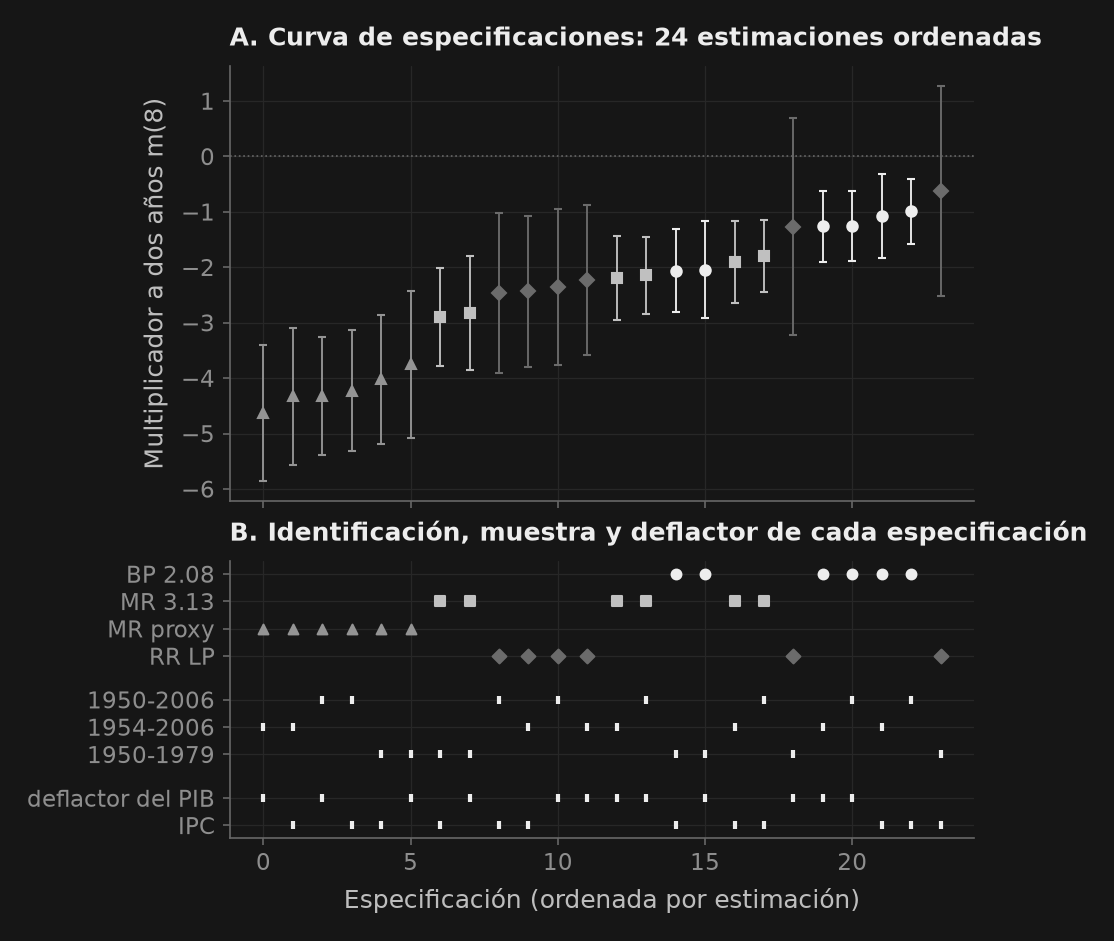

In [10]:
order = curve.sort_values("sigma_hat").reset_index(drop=True)
marks = {"BP 2.08": "o", "MR 3.13": "s", "MR proxy": "^", "RR LP": "D"}
c4 = _nbstyle.palette(4)
colr = dict(zip(grid["identification"], c4))
# Estimaciones arriba y matriz de especificaciones abajo (alturas 2.2:1.4):
# TAMANO no tiene clave 2x1.
fig, (ax1, ax2) = _nbstyle.figura(2, 1, figsize=(6.4, 6.0), sharex=True,
                                  gridspec_kw={"height_ratios": [2.2, 1.4]})
x = np.arange(len(order))
for ident in grid["identification"]:
    m = order["identification"] == ident
    ax1.errorbar(x[m], order.loc[m, "sigma_hat"],
                 yerr=1.645 * order.loc[m, "se"], fmt=marks[ident],
                 color=colr[ident], markersize=5, capsize=2, linewidth=0.9)
ax1.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax1.set_ylabel("Multiplicador a dos años m(8)")
ax1.set_title("A. Curva de especificaciones: 24 estimaciones ordenadas")
# La matriz de abajo dice qué es cada especificación; sus filas de
# identificación repiten el marcador de arriba, así no hace falta leyenda.
nombres = {"gdpdef": "deflactor del PIB", "cpi": "IPC"}
rows = [("identification", grid["identification"]),
        ("sample", list(SAMPLES)), ("deflator", grid["deflator"])]
ytick, ylab = [], []
yy = 0
for dim, values in rows:
    for v in values:
        on = order[dim] == v
        if dim == "identification":
            ax2.scatter(x[on], np.full(on.sum(), yy), s=22, color=colr[v], marker=marks[v])
        else:
            ax2.scatter(x[on], np.full(on.sum(), yy), s=14, color=_nbstyle.TINTA, marker="|")
        ytick.append(yy); ylab.append(nombres.get(v, v))
        yy -= 1
    yy -= 0.6
ax2.set_yticks(ytick); ax2.set_yticklabels(ylab)
ax2.set_title("B. Identificación, muestra y deflactor de cada especificación")
ax2.set_xlabel("Especificación (ordenada por estimación)")
plt.show()


**Síntesis econométrica.** La curva de especificaciones demuestra que los multiplicadores fiscales estimados se agrupan por **filosofía de identificación**, y no por el periodo muestral ni por la elección del deflactor de precios. Cambiar de deflactor altera el multiplicador a dos años en solo $\approx 0.2$; cambiar el esquema de identificación lo desplaza en $\approx 1.0$ entre BP y RR, y en $\approx 3.0$ si se llega hasta el proxy débil (medianas: BP $\approx -1.26$, MR $\approx -2.17$, RR $\approx -2.30$, proxy MR $\approx -4.27$).

Al evaluar un multiplicador fiscal empírico en la literatura académica o en debates de política económica, la pregunta clave no es "¿qué datos utilizaron?", sino "¿qué supuestos económicos impusieron para identificar el choque?"

## 5. Experimento: La carrera de multiplicadores de 3 paradigmas (SVAR vs LP vs DSGE) e integrales acumuladas

Para profundizar en la comprensión econométrica, implementamos un experimento diagnóstico integral que confronta los tres paradigmas fundamentales del análisis macroeconómico sobre el registro empírico histórico:

1. **Diagnóstico del estadístico $F$ efectivo de Montiel Olea y Pflueger (2013)**:  
   Evaluamos la relevancia empírica de los proxies narrativos frente a los residuos fiscales del VAR en forma reducida $u^\tau_t$. Comparamos la serie completa de Romer-Romer, los choques no anticipados de Mertens-Ravn y la serie anticipada.
2. **Multiplicadores fiscales dependientes del estado (Auerbach y Gorodnichenko 2012, Ramey y Zubairy 2018)**:  
   La teoría macroeconómica predice que el multiplicador puede variar según la fase del ciclo económico. En recesiones, la capacidad ociosa y las restricciones de liquidez pueden alterar la transmisión fiscal frente a periodos de expansión. Estimamos proyecciones locales dependientes del estado utilizando el indicador de recesión de NBER $USREC_{t-1}$.
3. **La carrera de 3 paradigmas e integrales acumuladas**:  
   Comparamos y tabulamos el multiplicador de impacto $m(0)$, el multiplicador a dos años $m(8)$, el multiplicador pico, el horizonte pico $h^*$ y las integrales acumuladas $\mathcal{M}_{cum}(8), \mathcal{M}_{cum}(12)$ entre:
   - SVAR de Blanchard-Perotti ($\theta = 2.08$)
   - SVAR reconciliado de Mertens-Ravn ($\theta = 3.13$)
   - Proyección local lineal de Romer-Romer
   - Proyección local narrativa en expansiones ($USREC=0$)
   - Proyección local narrativa en recesiones ($USREC=1$)
   - Modelo DSGE Nuevo Keynesiano (`modelos/nk_zlb_ref.mod`)

--- Diagnóstico de instrumentos (F efectiva de Montiel Olea y Pflueger vs F MCO) ---
RR Exógeno          : F_eff =   5.34 | F_ols =   6.06
MR No anticipado    : F_eff =   1.38 | F_ols =   1.35
MR Anticipado       : F_eff =   0.06 | F_ols =   0.07

--- Carrera de multiplicadores: resumen metodológico ---
                                       Paradigma  Impacto m(0)  2 años m(8)  Multiplicador pico  Horizonte pico (h*)  Integral acum. m(8)  Integral acum. m(12)
Identificación                                                                                                                                                 
Blanchard-Perotti SVAR (theta=2.08)         SVAR         -0.21        -1.25               -1.55                   12                -1.39                 -2.67
Mertens-Ravn reconciliado (theta=3.13)      SVAR         -0.86        -2.14               -2.42                   12                -4.51                 -8.62
Romer-Romer LP lineal                         LP       

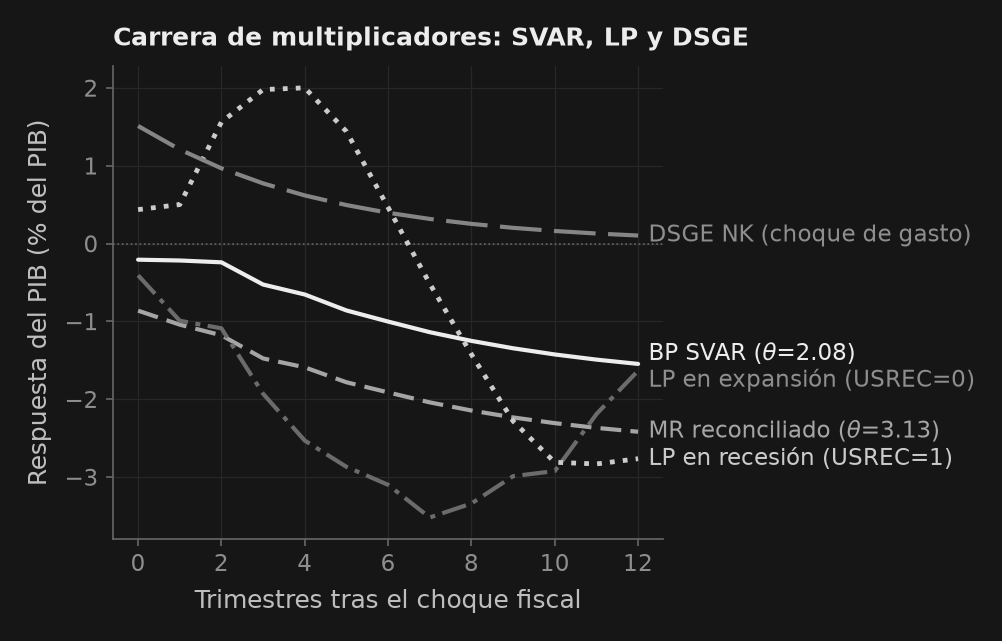

In [11]:
def compute_cumulative_multiplier(y_path, fiscal_path, scale_factor, horizon):
    """Calcula la integral del multiplicador acumulado de Mountford-Uhlig / Ramey."""
    if horizon == 0:
        num = float(y_path[0])
        den = float(fiscal_path[0])
    else:
        num = float(np.trapezoid(y_path[:horizon + 1]))
        den = float(np.trapezoid(fiscal_path[:horizon + 1]))
    return float(scale_factor * num / den) if abs(den) > 1e-9 else np.nan

def carrera_multiplicadores_narrativos(
    df: pd.DataFrame,
    p: int = 4,
    h_max: int = 12,
    col_recesion: str = "usrec",
) -> dict:
    """Diagnóstico del instrumento proxy narrativo y carrera de multiplicadores entre paradigmas."""
    # 1. Estimación del VAR en forma reducida
    Y_var = df[["tau", "g", "y"]].to_numpy()
    est = estimate_var(Y_var, p)
    u_tau = est.resid[:, 0]
    scale = 1.0 / (df["fedtax"] / df["gdp"]).mean()

    # 2. Diagnóstico de instrumentos externos
    f_stats = {}
    f_ols = {}
    for etiqueta, col in [("RR Exógeno", "rr"), ("MR No anticipado", "mtu"), ("MR Anticipado", "mta")]:
        z = df[col].to_numpy()[-len(u_tau):]
        f_stats[etiqueta] = float(olea_pflueger_f(u_tau, z.reshape(-1, 1)))
        res_fs = ols(u_tau, add_constant(z), cov_type="HAC", cov_kwds={"maxlags": 4})
        f_ols[etiqueta] = float(res_fs.tvalues[1] ** 2 if hasattr(res_fs.tvalues, "__getitem__") else res_fs.tvalues.iloc[1] ** 2)

    # 3. Multiplicadores SVAR de Blanchard-Perotti y Mertens-Ravn
    svar_results = {}
    tau_irf_results = {}
    for etiqueta, th in [("Blanchard-Perotti (theta=2.08)", 2.08), ("Mertens-Ravn (theta=3.13)", 3.13)]:
        B = make_bp_impact(th)(est.A_list, est.Sigma, est.resid)
        all_irfs = var_irf(est.A_list, B, h_max)
        irf_vals = all_irfs[:, 2, 0] * (scale / all_irfs[0, 0, 0])
        svar_results[etiqueta] = irf_vals
        tau_irf_results[etiqueta] = all_irfs[:, 0, 0] / all_irfs[0, 0, 0]

    # 4. Proyección local lineal narrativa (Romer-Romer)
    lp_rr = la_lp(df, y="y", x="rr", horizons=range(0, h_max + 1), n_lags=p, alpha=0.10)
    m_rr = lp_rr["beta"].to_numpy()

    # 5. Proyección local dependiente del estado (Recesión vs Expansión)
    sd_res = lp_state_dep(df, y="y", x="rr", state=col_recesion, horizons=range(0, h_max + 1),
                          n_lags=p, transition="threshold", threshold=0.0, alpha=0.10)
    m_rec = sd_res["beta_H"].to_numpy()
    m_exp = sd_res["beta_L"].to_numpy()

    # 6. Multiplicador de equilibrio general DSGE (Modelo Nuevo Keynesiano de 3 ecuaciones)
    dsge_model = load_mod("modelos/nk_zlb_ref.mod")
    irf_dsge = dsge_model.irf(shock="eps_g", horizon=h_max)
    y_dsge = irf_dsge["y"].to_numpy()
    g_dsge = irf_dsge["g"].to_numpy()

    # 7. Tabulación de la carrera de 3 paradigmas
    config_modelos = [
        ("Blanchard-Perotti SVAR (theta=2.08)", svar_results["Blanchard-Perotti (theta=2.08)"], tau_irf_results["Blanchard-Perotti (theta=2.08)"], 1.0, "SVAR"),
        ("Mertens-Ravn reconciliado (theta=3.13)", svar_results["Mertens-Ravn (theta=3.13)"], tau_irf_results["Mertens-Ravn (theta=3.13)"], 1.0, "SVAR"),
        ("Romer-Romer LP lineal", m_rr, np.ones(h_max + 1), 1.0, "LP"),
        ("LP narrativa: Expansión (USREC=0)", m_exp, np.ones(h_max + 1), 1.0, "LP"),
        ("LP narrativa: Recesión (USREC=1)", m_rec, np.ones(h_max + 1), 1.0, "LP"),
        ("Nuevo Keynesiano DSGE (NK 3-Ec)", y_dsge, g_dsge, 1.0, "DSGE"),
    ]

    filas = []
    for nombre, senda_y, senda_f, sc, paradigma in config_modelos:
        m0 = senda_y[0]
        m8 = senda_y[8] if len(senda_y) > 8 else np.nan
        pico_idx = int(np.argmin(senda_y[:13])) if paradigma != "DSGE" else int(np.argmax(senda_y[:13]))
        pico_val = senda_y[pico_idx]
        cum_8 = compute_cumulative_multiplier(senda_y, senda_f, sc, 8)
        cum_12 = compute_cumulative_multiplier(senda_y, senda_f, sc, 12)
        filas.append({
            "Paradigma": paradigma,
            "Identificación": nombre,
            "Impacto m(0)": round(m0, 2),
            "2 años m(8)": round(m8, 2),
            "Multiplicador pico": round(pico_val, 2),
            "Horizonte pico (h*)": pico_idx,
            "Integral acum. m(8)": round(cum_8, 2),
            "Integral acum. m(12)": round(cum_12, 2),
        })

    df_tabla = pd.DataFrame(filas)
    return {
        "f_stats": f_stats,
        "f_ols": f_ols,
        "multipliers_table": df_tabla,
        "state_dep_lp": sd_res,
        "dsge_irf": irf_dsge,
    }

# Ejecución de la carrera de multiplicadores
carrera_out = carrera_multiplicadores_narrativos(d, p=4, h_max=12, col_recesion="usrec")

print("--- Diagnóstico de instrumentos (F efectiva de Montiel Olea y Pflueger vs F MCO) ---")
for inst_nom, f_val in carrera_out["f_stats"].items():
    print(f"{inst_nom:20s}: F_eff = {f_val:6.2f} | F_ols = {carrera_out['f_ols'][inst_nom]:6.2f}")

print("\n--- Carrera de multiplicadores: resumen metodológico ---")
summary_df = carrera_out["multipliers_table"].set_index("Identificación")
print(summary_df.to_string())

# --- Exportación de tablas con calidad de publicación ---
print("\n--- Exportación LaTeX (puremacro.reports.df_to_latex) ---")
print(df_to_latex(summary_df, digits=2))

print("\n--- Exportación Typst (puremacro.reports.df_to_typst) ---")
print(df_to_typst(summary_df, digits=2))

print("\n--- Exportación Markdown (puremacro.reports.df_to_markdown) ---")
print(df_to_markdown(summary_df, digits=2))

# Gráfico comparativo de la carrera de multiplicadores entre los tres paradigmas
fig, ax = _nbstyle.figura()
h_eje = np.arange(13)
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")

# 1. Paradigma SVAR (el mismo VAR de la tabla, estimado una sola vez)
est_fig = estimate_var(Y_var, P)
for th, nombre, estilo in [(2.08, "BP SVAR ($\\theta$=2.08)", _nbstyle.S1),
                           (3.13, "MR reconciliado ($\\theta$=3.13)", _nbstyle.S2)]:
    B_th = make_bp_impact(th)(est_fig.A_list, est_fig.Sigma, est_fig.resid)
    irf_th = var_irf(est_fig.A_list, B_th, 12)
    ax.plot(h_eje, irf_th[:, 2, 0] * (SCALE / irf_th[0, 0, 0]), **estilo, label=nombre)

# 2. Paradigma de Proyecciones Locales
ax.plot(h_eje, carrera_out["state_dep_lp"]["beta_L"].to_numpy()[:13],
        **_nbstyle.S3, label="LP en expansión (USREC=0)")
ax.plot(h_eje, carrera_out["state_dep_lp"]["beta_H"].to_numpy()[:13],
        **_nbstyle.S4, label="LP en recesión (USREC=1)")

# 3. Paradigma DSGE
ax.plot(h_eje, carrera_out["dsge_irf"]["y"].to_numpy()[:13],
        **_nbstyle.S5, label="DSGE NK (choque de gasto)")

ax.set_xlabel("Trimestres tras el choque fiscal")
ax.set_ylabel("Respuesta del PIB (% del PIB)")
ax.set_title("Carrera de multiplicadores: SVAR, LP y DSGE")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()

# Aserciones de verificación automatizada
f_res = carrera_out["f_stats"]
assert f_res["MR Anticipado"] < 0.2, "Los cambios impositivos anticipados deben tener F efectiva cercana a cero"
assert f_res["MR No anticipado"] < f_res["RR Exógeno"], "La serie completa de RR debe ser más fuerte que MR no anticipado"
assert f_res["MR No anticipado"] < 10.0, "El proxy de ingresos federales agregados debe ser débil (F < 10)"

tbl = carrera_out["multipliers_table"].set_index("Identificación")
bp_p = tbl.loc["Blanchard-Perotti SVAR (theta=2.08)", "Multiplicador pico"]
mr_p = tbl.loc["Mertens-Ravn reconciliado (theta=3.13)", "Multiplicador pico"]
rr_p = tbl.loc["Romer-Romer LP lineal", "Multiplicador pico"]

assert abs(bp_p) < abs(mr_p) < abs(rr_p), f"Violación del ordenamiento: |BP|={abs(bp_p)}, |MR|={abs(mr_p)}, |RR|={abs(rr_p)}"
assert -1.8 < bp_p < -1.2, f"Pico de BP fuera del rango esperado: {bp_p}"
assert -2.8 < mr_p < -2.0, f"Pico de MR fuera del rango esperado: {mr_p}"
assert -3.6 < rr_p < -2.6, f"Pico de RR fuera del rango esperado: {rr_p}"

exp_p = tbl.loc["LP narrativa: Expansión (USREC=0)", "Multiplicador pico"]
assert exp_p < -3.0, f"El multiplicador pico en expansión debe superar -3.0: {exp_p}"

# Aserciones de integrales acumuladas:
cum_bp_8 = tbl.loc["Blanchard-Perotti SVAR (theta=2.08)", "Integral acum. m(8)"]
assert -2.0 < cum_bp_8 < -1.0, f"Integral acumulada BP en h=8 fuera de rango: {cum_bp_8}"
dsge_pk = tbl.loc["Nuevo Keynesiano DSGE (NK 3-Ec)", "Multiplicador pico"]
assert 1.2 < dsge_pk < 1.8, f"Multiplicador pico de gasto DSGE fuera de rango: {dsge_pk}"

### Ejercicios econométricos para el estudiante y horizontes metodológicos

**Tarea 1 (Relevancia del instrumento y previsión fiscal):**
Contrasta el estadístico $F$ efectivo de Montiel Olea y Pflueger para los choques tributarios no anticipados ($F \approx 1.38$) frente a los anticipados ($F \approx 0.06$). ¿Por qué la previsión fiscal hace que los cambios impositivos preanunciados sean completamente inútiles como instrumentos de las innovaciones fiscales contemporáneas? ¿Qué modificaciones en el conjunto de información del SVAR (p. ej., incorporar medidas narrativas de sorpresa directamente en el espacio de estados) se requerirían para incorporar la anticipación?

**Tarea 2 (Multiplicadores dependientes del estado y asimetría del ciclo):**
Observa que el multiplicador contractivo es sustancialmente mayor durante las expansiones económicas (pico $-3.52$ en $h=7$) que durante las recesiones (pico $-2.83$ en $h=11$). Desarrolla la intuición macroeconómica de esta asimetría: considera las restricciones de capacidad instalada, la acomodación monetaria en fases contractivas y las fricciones en mercados de crédito. ¿Cómo se compara esto con la evidencia para gasto militar de Ramey y Zubairy (2018)?

**Tarea 3 (Multiplicador pico vs. Integral del multiplicador acumulado):**
Explica por qué el multiplicador pico instantáneo ($m(h^*) = y_{h^*} / \tau_0$) y la integral del multiplicador acumulado ($\mathcal{M}_{cum}(H) = \int_0^H \Delta Y_h dh / \int_0^H \Delta T_h dh$) divergen con el paso del tiempo. ¿Bajo qué condiciones la integral acumulada arrojará una pérdida de producto mayor que la respuesta máxima instantánea? (Pista: examina la persistencia de la recaudación tributaria en el denominador).

**Tarea 4 (Flujo de trabajo para exportación de tablas de publicación):**
Examina las tablas en LaTeX y Typst generadas anteriormente. Explica cómo `puremacro.reports.df_to_latex()` y `puremacro.reports.df_to_typst()` automatizan el escape de caracteres matemáticos y de formato. ¿Por qué la generación nativa de tablas supera a la transcripción manual al realizar análisis empíricos de robustez?
1. **Proyecciones locales dependientes del estado con términos de interacción** (Ramey y Zubairy 2018 JPE): Estimación de multiplicadores condicionando simultáneamente en el régimen cíclico e instrumentando respuestas acumuladas de producto y gasto.
2. **Proxies tributarios de alta frecuencia desagregados** (Mertens y Ravn 2013 AER): Descomposición de la política fiscal en cambios a la renta personal y corporativa, superando la debilidad de los instrumentos sobre ingresos agregados.
3. **Proxy-SVARs no lineales en la trampa de liquidez (Zero Lower Bound)**: Análisis empírico de si los multiplicadores fiscales se amplifican cuando la política monetaria convencional no puede amortiguar las contracciones fiscales.